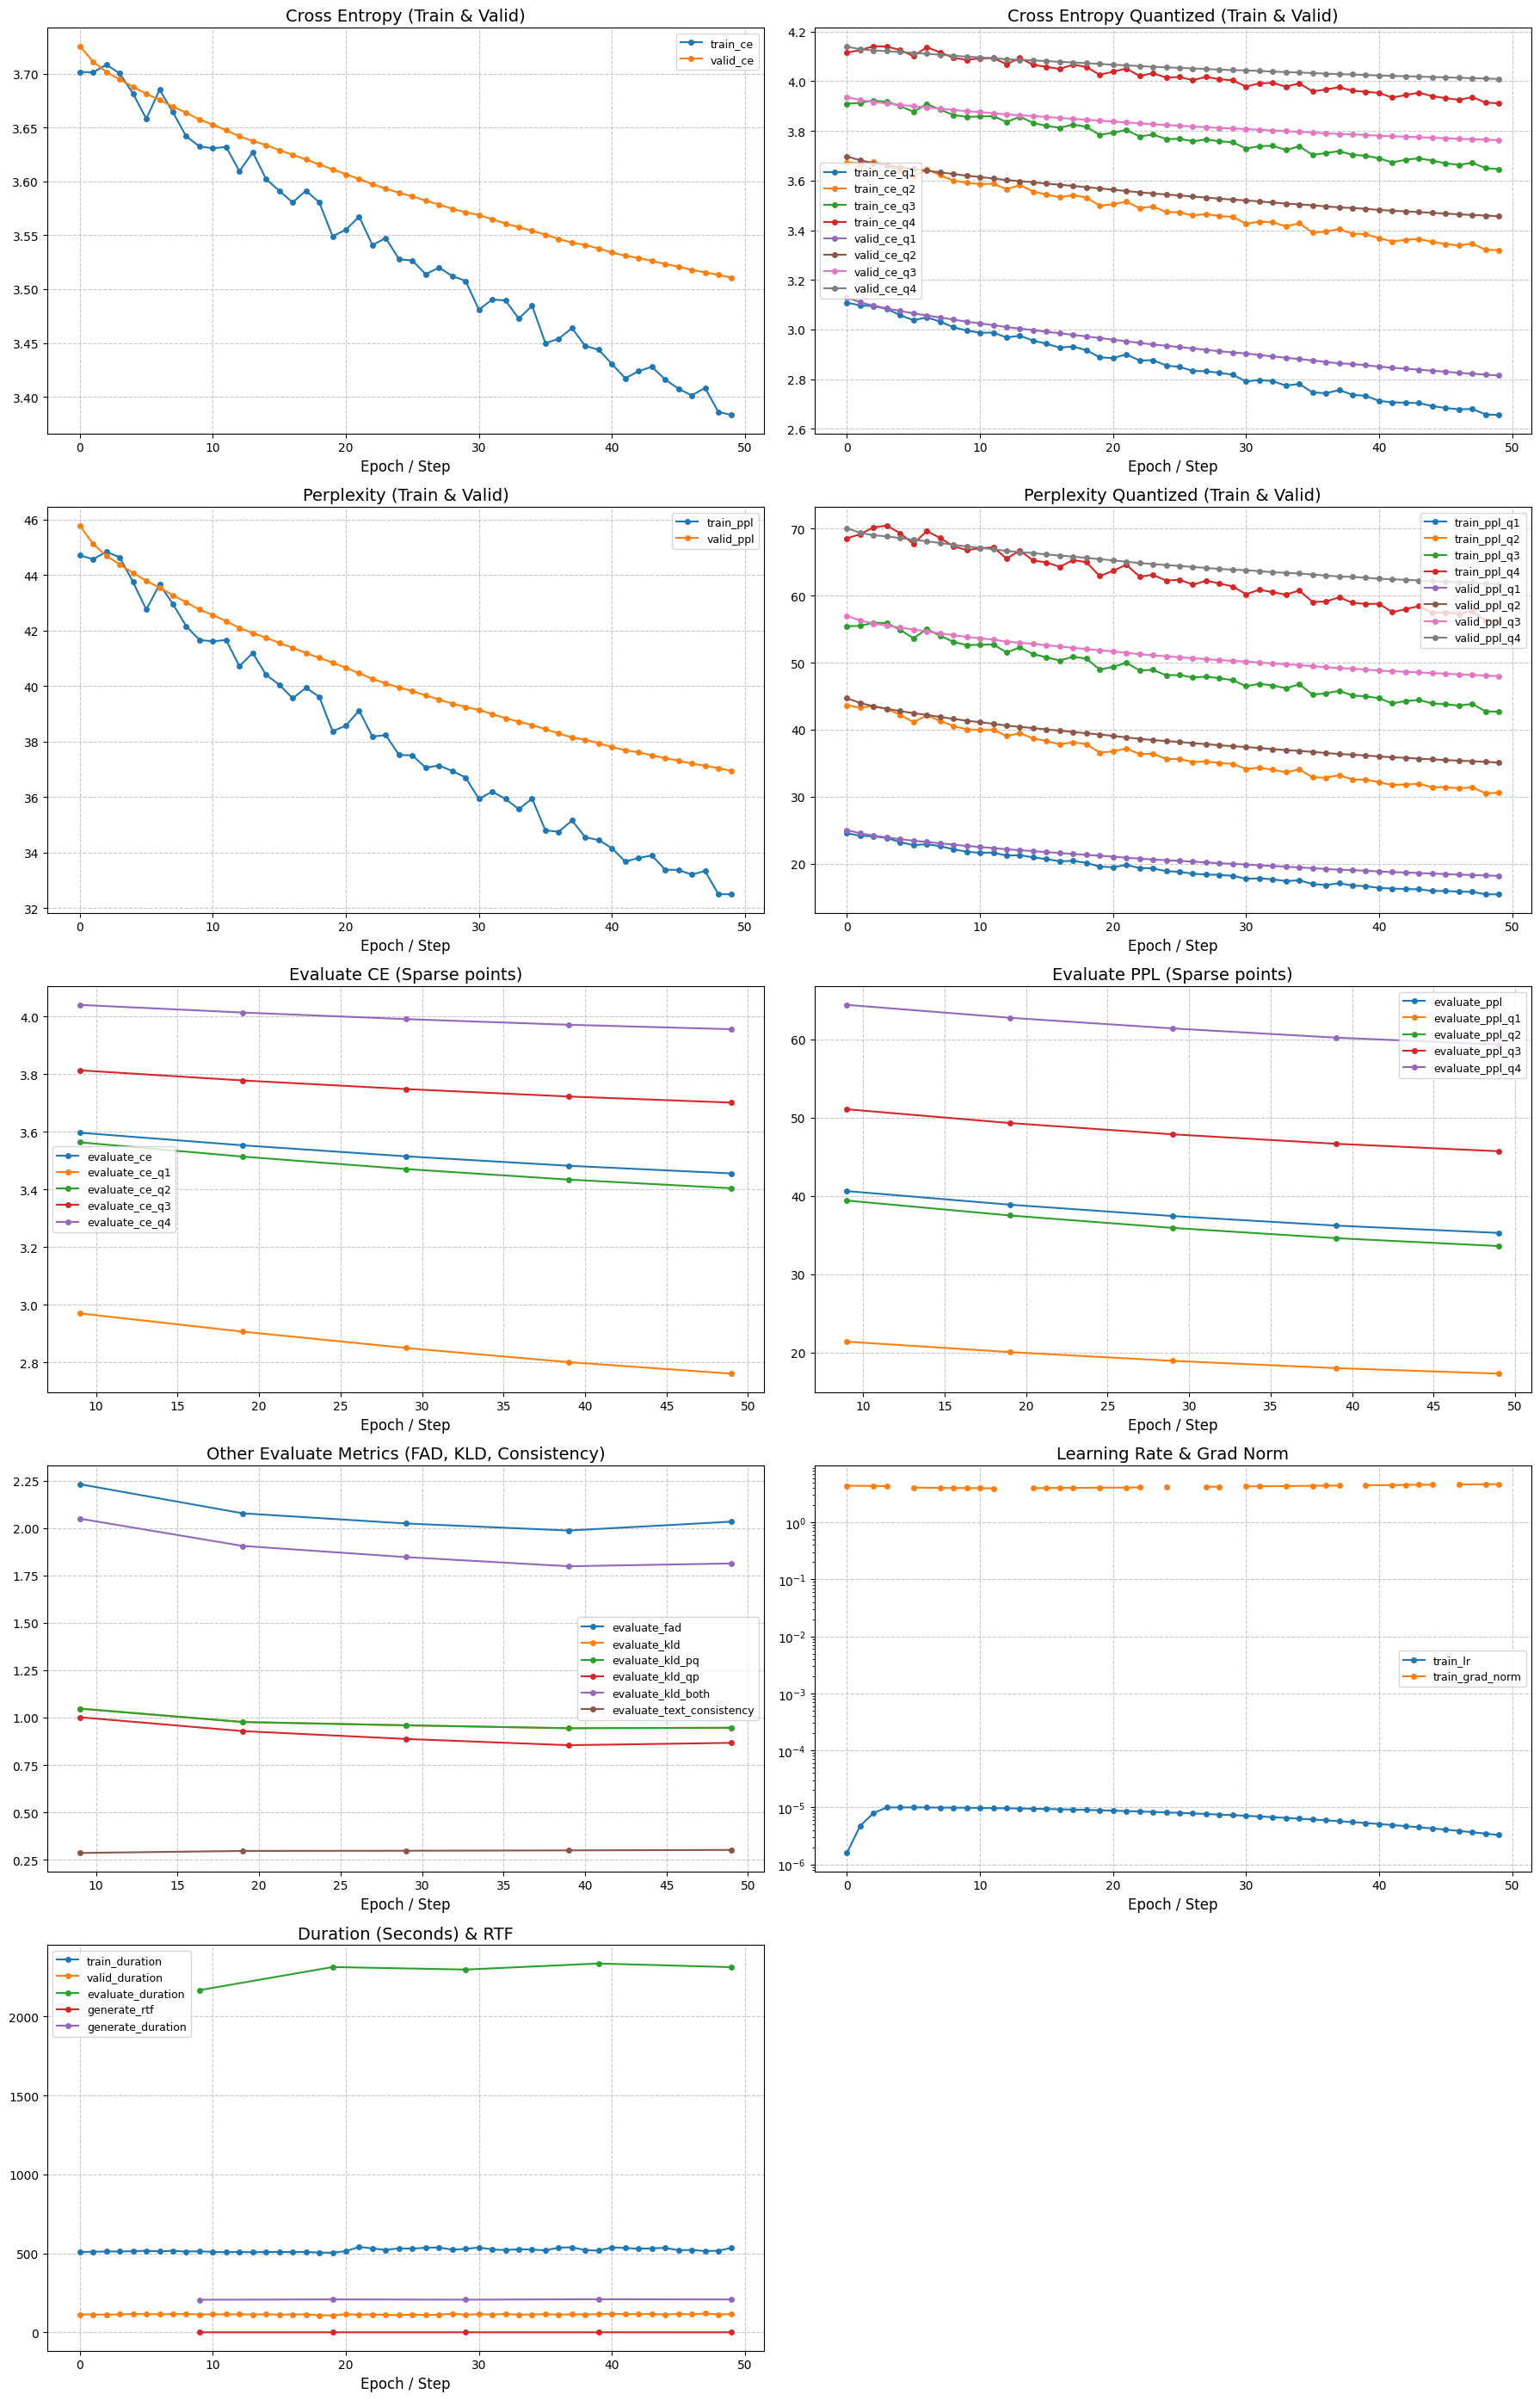

In [7]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
with open('/storage/ssd1/richtsai1103/MusicBench/dora_outputs/20260326_011111/xps/02fff126/history.json', 'r') as f:
    data = json.load(f)

# Flatten the data into a list of dictionaries to create a DataFrame
records = []
for i, step in enumerate(data):
    row = {'step': i}
    for phase, metrics in step.items():
        for k, v in metrics.items():
            row[f"{phase}_{k}"] = v
    records.append(row)

df = pd.DataFrame(records)

# Group metrics to plot them in logical subplots
ce_cols = [c for c in df.columns if 'ce' in c and 'ce_q' not in c and 'evaluate' not in c]
ce_q_cols = [c for c in df.columns if 'ce_q' in c and 'evaluate' not in c]
ppl_cols = [c for c in df.columns if 'ppl' in c and 'ppl_q' not in c and 'evaluate' not in c]
ppl_q_cols = [c for c in df.columns if 'ppl_q' in c and 'evaluate' not in c]

# Group evaluate specific stuff (Separated eval CE and PPL)
eval_ce = [c for c in df.columns if 'evaluate' in c and 'ce' in c]
eval_ppl = [c for c in df.columns if 'evaluate' in c and 'ppl' in c]
eval_other = [c for c in df.columns if 'evaluate' in c and 'ce' not in c and 'ppl' not in c and 'duration' not in c]

dur_cols = [c for c in df.columns if 'duration' in c or 'rtf' in c]
other_train_cols = ['train_lr']
grad_cols = ['train_grad_norm', 'train_grad_scale']

# Create subplots - Changed to 5x2 to fit the 9th plot
fig, axes = plt.subplots(5, 2, figsize=(18, 28))
axes = axes.flatten()

def plot_cols(ax, cols, title, logy=False):
    for c in cols:
        if c in df.columns:
            # For sparse metrics (like evaluate), drop NAs so lines/points connect properly
            valid_data = df[['step', c]].dropna()
            ax.plot(valid_data['step'], valid_data[c], label=c, marker='o', markersize=4)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Epoch / Step', fontsize=12)
    if logy:
        ax.set_yscale('log')
    ax.legend(fontsize='9', loc='best')
    ax.grid(True, linestyle='--', alpha=0.7)

# Plotting each group into the designated subplot
plot_cols(axes[0], ce_cols, 'Cross Entropy (Train & Valid)')
plot_cols(axes[1], ce_q_cols, 'Cross Entropy Quantized (Train & Valid)')
plot_cols(axes[2], ppl_cols, 'Perplexity (Train & Valid)')
plot_cols(axes[3], ppl_q_cols, 'Perplexity Quantized (Train & Valid)')

# Separated the Evaluate metrics
plot_cols(axes[4], eval_ce, 'Evaluate CE (Sparse points)')
plot_cols(axes[5], eval_ppl, 'Evaluate PPL (Sparse points)')

plot_cols(axes[6], eval_other, 'Other Evaluate Metrics (FAD, KLD, Consistency)')
plot_cols(axes[7], ['train_lr', 'train_grad_norm'], 'Learning Rate & Grad Norm', logy=True)
plot_cols(axes[8], dur_cols, 'Duration (Seconds) & RTF')

# Hide the empty 10th subplot
axes[9].set_visible(False)

plt.tight_layout()
plt.savefig('history_metrics.png', dpi=150, bbox_inches='tight')